### Imports
    - Pandas for ETL
    - SQLite is a lighweight SQL Database

In [1]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("la_sales.sqlite") #local server 

## EXTRACT from DATA Sources

    - Flat files -read_csv(), read_json(), read_parquet()
        - Append Multiple Files

    - Datanbases - pd.read_sql() + sqlalchemy
    - APIs - tap into web based resources

In [2]:
sales_df = pd.read_csv("LA_Retail_Sales.csv")

sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          750 non-null    str    
 1   store_name        750 non-null    str    
 2   product_category  750 non-null    str    
 3   date              750 non-null    str    
 4   Unit sales        745 non-null    float64
 5   DOLLAR SALES      743 non-null    float64
 6   store_zip         750 non-null    str    
 7   promotion_flag    750 non-null    bool   
dtypes: bool(1), float64(2), str(5)
memory usage: 65.8 KB


In [3]:
import glob

file_paths = glob.glob("LA_retail_day_by_day/*.csv")

df_sales2 = pd.concat([pd.read_csv(fp) for fp in file_paths], ignore_index = True)
df_sales2.info()


<class 'pandas.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          750 non-null    str    
 1   store_name        750 non-null    str    
 2   product_category  750 non-null    str    
 3   date              750 non-null    str    
 4   unit_sales        745 non-null    float64
 5   dollar_sales      743 non-null    float64
 6   store_zip         750 non-null    str    
 7   promotion_flag    750 non-null    bool   
dtypes: bool(1), float64(2), str(5)
memory usage: 68.2 KB


In [4]:
df_sales2 = pd.DataFrame()  # just clearing the previous data frame


for day in range(1,6): # iterate for 5 days
    print(day)
    day_df = pd.read_csv(f"LA_retail_day_by_day/sales_2024-09-{day:02d}.csv") # f-string is use to padd the days in the file_path
    df_sales2 = pd.concat([df_sales2,day_df])
    print(len(df_sales2))
df_sales2

1
30
2
57
3
81
4
97
5
120


,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag
0,LA002,Store_2,Household,2024-09-01,16.0,96.28,90004,True
1,LA001,Store_1,Beverages,2024-09-01,14.0,86.63,90004,True
2,LA008,Store_8,Produce,2024-09-01,4.0,79.99,90001,False
3,LA010,Store_10,Beverages,2024-09-01,22.0,140.45,90005,True
4,LA006,Store_6,Snacks,2024-09-01,17.0,50.03,90003,False
...,...,...,...,...,...,...,...,...
18,LA002,Store_2,Household,2024-09-05,2.0,16.21,90004,False
19,LA010,Store_10,Beverages,2024-09-05,45.0,469.30,90004,False
20,LA002,Store_2,Snacks,2024-09-05,20.0,210.86,90001,False
21,LA005,Store_5,Snacks,2024-09-05,9.0,176.94,90004,False


In [5]:
sales_df_json = pd.read_json("LA_Retail_Sales.json", lines=True) # lines=True is telling pandas that its a json lines format
sales_df_json

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag
0,LA002,Store_2,Household,2024-09-01,16.0,96.28,90004,True
1,LA001,Store_1,Beverages,2024-09-01,14.0,86.63,90004,True
2,LA004,Store_4,Produce,2024-09-15,18.0,298.26,90003,True
3,LA003,Store_3,Household,2024-09-07,7.0,25.69,90001,True
4,LA008,Store_8,Beverages,2024-09-18,25.0,85.46,90005,False
...,...,...,...,...,...,...,...,...
745,LA010,Store_10,Beverages,2024-09-24,46.0,790.99,90005,True
746,LA008,Store_8,Snacks,2024-09-14,23.0,375.40,90003,False
747,LA004,Store_4,Personal Care,2024-09-14,17.0,225.24,900XX,False
748,LA009,Store_9,Snacks,2024-09-28,37.0,406.47,90004,False


In [6]:
pip install pandas pyarrow 

Note: you may need to restart the kernel to use updated packages.


In [7]:
sales_df_parquet = pd.read_parquet("LA_Retail_Sales.parquet")
sales_df_parquet

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag
0,LA002,Store_2,Household,2024-09-01,16.0,96.28,90004,True
1,LA001,Store_1,Beverages,2024-09-01,14.0,86.63,90004,True
2,LA004,Store_4,Produce,2024-09-15,18.0,298.26,90003,True
3,LA003,Store_3,Household,2024-09-07,7.0,25.69,90001,True
4,LA008,Store_8,Beverages,2024-09-18,25.0,85.46,90005,False
...,...,...,...,...,...,...,...,...
745,LA010,Store_10,Beverages,2024-09-24,46.0,790.99,90005,True
746,LA008,Store_8,Snacks,2024-09-14,23.0,375.40,90003,False
747,LA004,Store_4,Personal Care,2024-09-14,17.0,225.24,900XX,False
748,LA009,Store_9,Snacks,2024-09-28,37.0,406.47,90004,False


## SQL

In [8]:
sales_df = pd.read_sql("SELECT * FROM Sales", con=conn)

In [9]:
import matplotlib.pyplot as plt

<Axes: xlabel='store_id'>

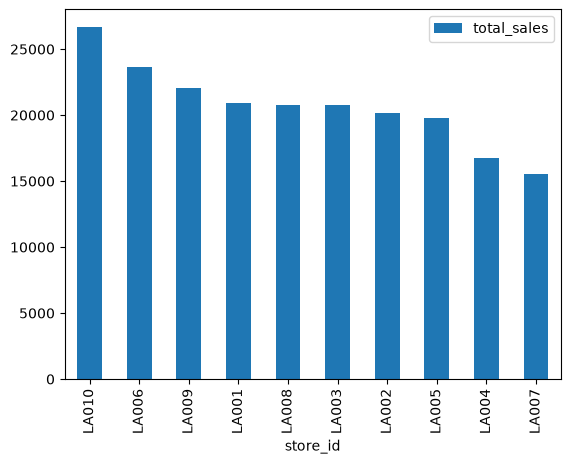

In [10]:
pd.read_sql("""
SELECT store_id,
       SUM(dollar_sales) as total_sales
       
FROM 
    Sales
GROUP BY
    store_id
ORDER BY 
    total_sales DESC
""",conn).set_index("store_id").plot.bar()

## API

In [11]:
import requests
import time
from datetime import datetime
 



In [12]:
sales_df["date"] = pd.to_datetime(sales_df['date'])
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 738 entries, 0 to 737
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   store_id          738 non-null    str           
 1   store_name        738 non-null    str           
 2   product_category  738 non-null    str           
 3   date              738 non-null    datetime64[us]
 4   unit_sales        738 non-null    int64         
 5   dollar_sales      738 non-null    float64       
 6   store_zip         738 non-null    str           
 7   promotion_flag    738 non-null    int64         
 8   rev_per_unit      738 non-null    float64       
 9   temp              738 non-null    float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(4)
memory usage: 76.4 KB


In [13]:
API_KEY = "8f315b5d1f5cf4fafcafa2a00cab7e96"
LAT, LON = 34.0522 , -118.2437 # coordinates for los Angles

unix_timestamp = int(datetime.strptime(str(sales_df["date"][0].date()),"%Y-%m-%d").timestamp())
end  = int(datetime.strptime(str(sales_df["date"][737].date()),"%Y-%m-%d").timestamp())

# 3. The Live API Endpoint URL (Notice the 'api.' subdomain)
url = "https://api.openweathermap.org/data/3.0/onecall/timemachine"

params = {
    "lat": LAT,
    "lon": LON,
    "dt": unix_timestamp,
    "appid": API_KEY,
    "units": "imperial"  # Options: 'metric', 'imperial', or 'standard'
}



print("Pinging OpenWeatherMap...")
response = requests.get(url, params = params)

# 6. Evaluate output
if response.status_code == 200:
    data = response.json()
    print("Success! Data received:")
    print(data)
else:
    print(f"Failed with Status Code: {response.status_code}")
    print(response.text)

Pinging OpenWeatherMap...
Failed with Status Code: 401
{"cod":401, "message": "Please note that using One Call 3.0 requires a separate subscription to the One Call by Call plan. Learn more here https://openweathermap.org/price. If you have a valid subscription to the One Call by Call plan, but still receive this error, then please see https://openweathermap.org/faq#error401 for more info."}


## will going back to this some other time. The example here is vey outdated, and it needs payment to proceed.

# Transform Panda Data

In [14]:
sales_df = pd.read_csv("LA_Retail_Sales.csv")

sales_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          750 non-null    str    
 1   store_name        750 non-null    str    
 2   product_category  750 non-null    str    
 3   date              750 non-null    str    
 4   Unit sales        745 non-null    float64
 5   DOLLAR SALES      743 non-null    float64
 6   store_zip         750 non-null    str    
 7   promotion_flag    750 non-null    bool   
dtypes: bool(1), float64(2), str(5)
memory usage: 65.8 KB


In [15]:
sales_df.columns.str.lower().str.replace(" ", "_")
 # make columns consistent                                       

Index(['store_id', 'store_name', 'product_category', 'date', 'unit_sales',
       'dollar_sales', 'store_zip', 'promotion_flag'],
      dtype='str')

In [16]:
sales_df.columns =  sales_df.columns.str.lower().str.replace(" ", "_")
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          750 non-null    str    
 1   store_name        750 non-null    str    
 2   product_category  750 non-null    str    
 3   date              750 non-null    str    
 4   unit_sales        745 non-null    float64
 5   dollar_sales      743 non-null    float64
 6   store_zip         750 non-null    str    
 7   promotion_flag    750 non-null    bool   
dtypes: bool(1), float64(2), str(5)
memory usage: 65.8 KB


In [17]:
# unit_sales,dollar_sales has null values

sales_df.query("unit_sales.isna()")

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag
25,LA007,Store_7,Personal Care,9/16/24,NaN,245.89,90004,True
301,LA002,Store_2,Personal Care,9/21/24,NaN,8.47,90002,True
395,LA009,Store_9,household,9/7/24,NaN,18.06,90002,True
501,LA007,Store_7,Personal Care,9/28/24,NaN,60.13,90002,True
651,LA009,Store_9,Personal Care,9/23/24,NaN,305.32,90004,True


In [18]:
missing_unit_indices = sales_df.query("unit_sales.isna()").index
print(missing_unit_indices)

sales_df["unit_sales"] = sales_df["unit_sales"].fillna(0)

sales_df.iloc[[25,301,395,501,651]]

Index([25, 301, 395, 501, 651], dtype='int64')


,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag
25,LA007,Store_7,Personal Care,9/16/24,0.0,245.89,90004,True
301,LA002,Store_2,Personal Care,9/21/24,0.0,8.47,90002,True
395,LA009,Store_9,household,9/7/24,0.0,18.06,90002,True
501,LA007,Store_7,Personal Care,9/28/24,0.0,60.13,90002,True
651,LA009,Store_9,Personal Care,9/23/24,0.0,305.32,90004,True


In [19]:
# if need to drop null values

sales_df = pd.read_csv("LA_Retail_Sales.csv") # return to the original DF
sales_df.columns =  sales_df.columns.str.lower().str.replace(" ", "_")


sales_df = sales_df.dropna(subset =["unit_sales","dollar_sales"])
sales_df.info()

<class 'pandas.DataFrame'>
Index: 738 entries, 0 to 749
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          738 non-null    str    
 1   store_name        738 non-null    str    
 2   product_category  738 non-null    str    
 3   date              738 non-null    str    
 4   unit_sales        738 non-null    float64
 5   dollar_sales      738 non-null    float64
 6   store_zip         738 non-null    str    
 7   promotion_flag    738 non-null    bool   
dtypes: bool(1), float64(2), str(5)
memory usage: 70.8 KB


In [20]:
# adding calculated column
sales_df["rev_per_unit"] = (sales_df["dollar_sales"] / sales_df["unit_sales"]).round(2) 
sales_df.head()

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag,rev_per_unit
0,LA002,Store_2,Household,9/1/24,16.0,96.28,90004,True,6.02
1,LA001,Store_1,Beverages,9/1/24,14.0,86.63,90004,True,6.19
2,LA004,Store_4,Produce,9/15/24,18.0,298.26,90003,True,16.57
3,LA003,Store_3,Household,9/7/24,7.0,25.69,90001,True,3.67
4,LA008,Store_8,Beverages,9/18/24,25.0,85.46,90005,False,3.42


In [21]:
sales_df["store_zip"].value_counts()
# replace 'XX' to "00"

sales_df["store_zip"] = sales_df["store_zip"].str.replace('XX','00')
sales_df["store_zip"].value_counts()

store_zip
90003    137
90004    133
90001    124
90005    122
90000    118
90002    104
Name: count, dtype: int64

In [22]:
sales_df.info()

<class 'pandas.DataFrame'>
Index: 738 entries, 0 to 749
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          738 non-null    str    
 1   store_name        738 non-null    str    
 2   product_category  738 non-null    str    
 3   date              738 non-null    str    
 4   unit_sales        738 non-null    float64
 5   dollar_sales      738 non-null    float64
 6   store_zip         738 non-null    str    
 7   promotion_flag    738 non-null    bool   
 8   rev_per_unit      738 non-null    float64
dtypes: bool(1), float64(3), str(5)
memory usage: 76.5 KB


In [23]:
sales_df["date"] = pd.to_datetime(sales_df["date"], format = 'mixed')
sales_df.info()
sales_df.head()

<class 'pandas.DataFrame'>
Index: 738 entries, 0 to 749
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   store_id          738 non-null    str           
 1   store_name        738 non-null    str           
 2   product_category  738 non-null    str           
 3   date              738 non-null    datetime64[us]
 4   unit_sales        738 non-null    float64       
 5   dollar_sales      738 non-null    float64       
 6   store_zip         738 non-null    str           
 7   promotion_flag    738 non-null    bool          
 8   rev_per_unit      738 non-null    float64       
dtypes: bool(1), datetime64[us](1), float64(3), str(4)
memory usage: 71.6 KB


,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag,rev_per_unit
0,LA002,Store_2,Household,2024-09-01,16.0,96.28,90004,True,6.02
1,LA001,Store_1,Beverages,2024-09-01,14.0,86.63,90004,True,6.19
2,LA004,Store_4,Produce,2024-09-15,18.0,298.26,90003,True,16.57
3,LA003,Store_3,Household,2024-09-07,7.0,25.69,90001,True,3.67
4,LA008,Store_8,Beverages,2024-09-18,25.0,85.46,90005,False,3.42


In [24]:
sales_df.describe()

,date,unit_sales,dollar_sales,rev_per_unit
count,738,738.000000,738.000000,738.000000
mean,2024-09-15 11:46:20.487805,25.636856,280.526016,10.944715
min,2024-09-01 00:00:00,1.000000,5.330000,2.030000
25%,2024-09-08 06:00:00,13.000000,105.955000,6.547500
50%,2024-09-16 00:00:00,26.000000,224.910000,10.830000
75%,2024-09-23 00:00:00,38.000000,409.212500,15.310000
max,2024-09-30 00:00:00,50.000000,980.000000,20.000000
std,NaN,14.353205,217.325468,5.133041


<Axes: ylabel='Frequency'>

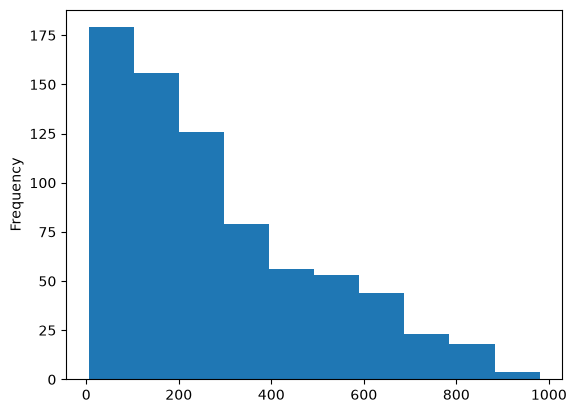

In [25]:
sales_df["dollar_sales"].plot.hist()

<Axes: xlabel='dollar_sales', ylabel='Count'>

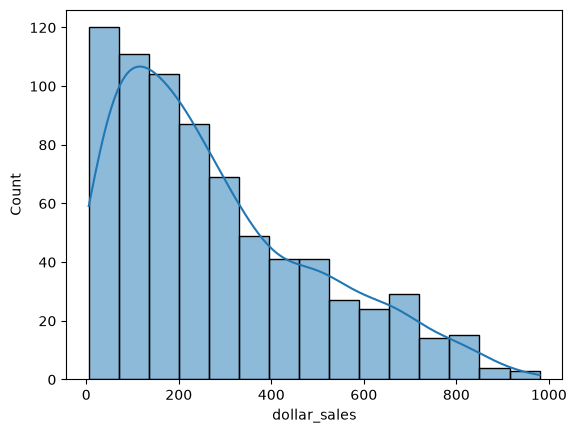

In [34]:
import seaborn as sns

sns.histplot(data = sales_df ,x = "dollar_sales", kde= " True") 

### MERGE dataset

In [43]:
weather_data = pd.read_csv("LA_Weather_Data.csv")
weather_data["date"] = pd.to_datetime(weather_data["date"],format ="mixed")

In [59]:
sales_df = sales_df.merge(weather_data[["date","temp"]], how = "left" ,on ="date")
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 738 entries, 0 to 737
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   store_id          738 non-null    str           
 1   store_name        738 non-null    str           
 2   product_category  738 non-null    str           
 3   date              738 non-null    datetime64[us]
 4   unit_sales        738 non-null    float64       
 5   dollar_sales      738 non-null    float64       
 6   store_zip         738 non-null    str           
 7   promotion_flag    738 non-null    bool          
 8   rev_per_unit      738 non-null    float64       
 9   temp              738 non-null    float64       
dtypes: bool(1), datetime64[us](1), float64(4), str(4)
memory usage: 71.7 KB


### LOAD INTO SQL

In [60]:
sales_df.to_sql("weather", if_exists = "replace" , index = False,con = conn)

738

In [61]:
pd.read_sql("SELECT * FROM weather WHERE temp > 70", con= conn)

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag,rev_per_unit,temp
0,LA002,Store_2,Household,2024-09-01 00:00:00,16.0,96.28,90004,1,6.02,71.19
1,LA001,Store_1,Beverages,2024-09-01 00:00:00,14.0,86.63,90004,1,6.19,71.19
2,LA003,Store_3,Household,2024-09-07 00:00:00,7.0,25.69,90001,1,3.67,78.37
3,LA009,Store_9,Household,2024-09-08 00:00:00,50.0,798.40,90001,1,15.97,85.53
4,LA003,Store_3,Produce,2024-09-08 00:00:00,35.0,235.53,90002,0,6.73,85.53
...,...,...,...,...,...,...,...,...,...,...
231,LA009,Store_9,Snacks,2024-09-09 00:00:00,50.0,509.17,90002,1,10.18,85.93
232,LA001,Store_1,Beverages,2024-09-04 00:00:00,5.0,54.83,90002,1,10.97,76.75
233,LA009,Store_9,Produce,2024-09-09 00:00:00,22.0,364.55,90001,1,16.57,85.93
234,LA006,Store_6,Snacks,2024-09-02 00:00:00,16.0,99.57,90003,0,6.22,71.82
